# Notebook 4 — Patient Similarity with a Multi-Omics Kernel and Graph Attention

**Use case:** patient similarity and graph representation learning  
**Dataset:** TCGA-BRCA frozen cohort (617 primary tumour samples)  
**Modalities:** RNA-seq, miRNA, and DNA methylation  
**Runtime target:** 15–20 minutes including discussion

## Scientific question

> Can relationships between molecularly similar patients become part of a patient representation?

Notebook 1 learned a compact representation of each patient.  
Notebook 2 learned shared structure between molecular views.  
Notebook 3 learned multi-view factors and modality contributions.  
Here we change the question again: can relationships between molecularly similar patients themselves become part of the representation?

We first turn the frozen multi-omics representation into a patient-similarity kernel. We then make a top-5 nearest-neighbour graph and train a self-supervised Graph Attention Network (GAT) on it. **PAM50 is never used to construct the graph or train the GAT; it is used only afterward for external evaluation.**

## 1. Load the frozen multi-omics representation

This cell loads the cohort and the three already processed molecular matrices from the earlier notebooks. Each row is one patient, and their order is fixed across views. We check that alignment once here, because all later similarities and graph edges depend on it.

In [1]:
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel, pairwise_distances
from sklearn.decomposition import KernelPCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURE_DIR = PROCESSED_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_DIR}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Random seed: {SEED}")

Project root: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop
Processed data: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed
Random seed: 42


In [2]:
paths = {
    "cohort": PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
    "rna": PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",
    "mirna": PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv",
    "methylation": PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv",
}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")

cohort = pd.read_csv(paths["cohort"], sep="\t", index_col="sample_id")
rna = pd.read_csv(paths["rna"], sep="\t", index_col=0)
mirna = pd.read_csv(paths["mirna"], sep="\t", index_col=0)
methylation = pd.read_csv(paths["methylation"], sep="\t", index_col=0)

frozen_ids = cohort.index.tolist()
assert len(frozen_ids) == 617
assert rna.shape == (617, 1000)
assert mirna.shape == (617, 300)
assert methylation.shape == (617, 1000)
assert list(rna.index) == frozen_ids
assert list(mirna.index) == frozen_ids
assert list(methylation.index) == frozen_ids
assert rna.isna().sum().sum() == 0
assert mirna.isna().sum().sum() == 0
assert methylation.isna().sum().sum() == 0
assert rna.columns.is_unique and mirna.columns.is_unique and methylation.columns.is_unique

print("Data-integrity checks passed:")
print(f"  Frozen cohort : {len(frozen_ids)} samples")
print(f"  RNA-seq       : {rna.shape}")
print(f"  miRNA         : {mirna.shape}")
print(f"  Methylation   : {methylation.shape}")
print("  Identical sample order, zero missing values, unique features: confirmed")

Data-integrity checks passed:
  Frozen cohort : 617 samples
  RNA-seq       : (617, 1000)
  miRNA         : (617, 300)
  Methylation   : (617, 1000)
  Identical sample order, zero missing values, unique features: confirmed


## 2. Build an integrated patient-similarity kernel and a top-5 graph

We standardize each molecular view separately, convert patient distances into RBF similarities, and average the three kernels with equal weights. A **node** is a patient; an **edge** points to one of that patient's five most molecularly similar neighbours. PAM50 is deliberately absent from this construction: the graph contains only molecular similarity.

In [3]:
def standardize_matrix(dataframe):
    return StandardScaler().fit_transform(dataframe.values).astype(np.float32)

def median_distance_gamma(matrix):
    distances_squared = pairwise_distances(matrix, metric="sqeuclidean")
    return 1.0 / (2.0 * np.median(distances_squared[distances_squared > 0]))

scaled = {"RNA": standardize_matrix(rna), "miRNA": standardize_matrix(mirna),
          "Methylation": standardize_matrix(methylation)}
gammas = {name: median_distance_gamma(matrix) for name, matrix in scaled.items()}
kernels = {name: rbf_kernel(matrix, gamma=gammas[name]).astype(np.float32)
           for name, matrix in scaled.items()}
normalized_kernels = {name: kernel * (len(frozen_ids) / np.trace(kernel))
                      for name, kernel in kernels.items()}
K_multi = sum(normalized_kernels.values()) / len(normalized_kernels)

K_NEIGHBORS = 5
knn_edges, neighbor_rows = [], []
for i, sample_id in enumerate(frozen_ids):
    similarity = K_multi[i].copy(); similarity[i] = -np.inf
    neighbour_indices = np.argsort(similarity)[::-1][:K_NEIGHBORS]
    row = {"sample_id": sample_id, "patient_id": cohort.loc[sample_id, "patient_id"]}
    for rank, j in enumerate(neighbour_indices, start=1):
        knn_edges.append((i, int(j), float(K_multi[i, j])))
        row[f"nearest_patient_{rank}"] = cohort.loc[frozen_ids[j], "patient_id"]
        row[f"similarity_{rank}"] = float(K_multi[i, j])
    neighbor_rows.append(row)
neighbors_df = pd.DataFrame(neighbor_rows).set_index("sample_id")

assert K_multi.shape == (617, 617) and np.isfinite(K_multi).all()
print(f"Integrated kernel: {K_multi.shape}; top-{K_NEIGHBORS} graph: {len(knn_edges)} directed edges")
print("PAM50 was not used to construct the kernel or graph.")

Integrated kernel: (617, 617); top-5 graph: 3085 directed edges
PAM50 was not used to construct the kernel or graph.


## 3. See patients as a similarity graph

Kernel PCA gives a two-dimensional view of the integrated similarity matrix; the sparse lines show only top-5 graph edges. Nearby nodes and connected nodes have similar multi-omics profiles. PAM50 colours are added only after the graph is built, so use them to interpret the structure rather than to explain how it was learned.

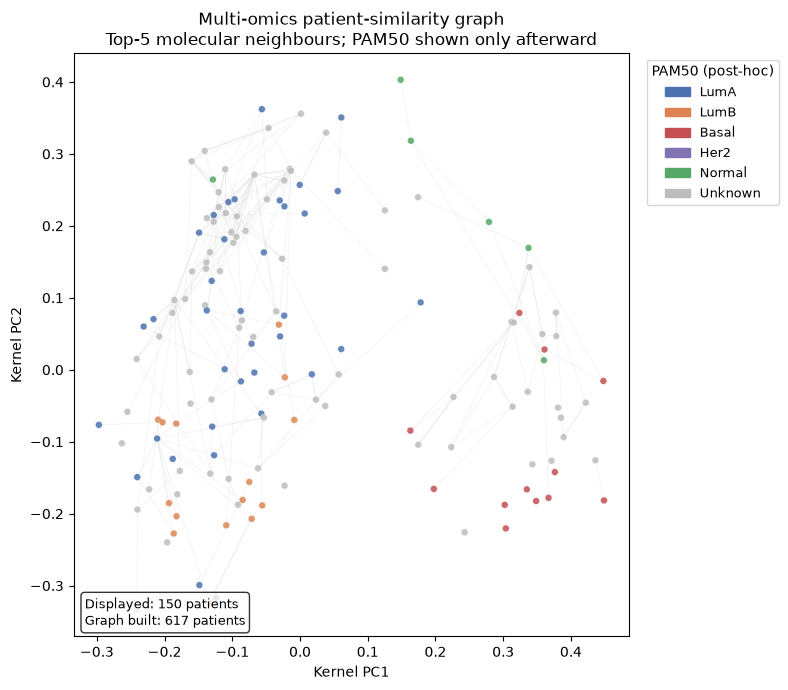

In [4]:
kpca = KernelPCA(n_components=2, kernel="precomputed", random_state=SEED)
embedding = kpca.fit_transform(K_multi)
embedding_df = pd.DataFrame(embedding, index=frozen_ids, columns=["PC1", "PC2"])
embedding_df.index.name = "sample_id"
pam50 = cohort["PAM50_subtype"].reindex(frozen_ids).fillna("Unknown")
colors = {"LumA": "#4C72B0", "LumB": "#DD8452", "Basal": "#C44E52", "Her2": "#8172B3", "Normal": "#55A868", "Unknown": "#BDBDBD"}
subset_n = min(150, len(frozen_ids))
fig, ax = plt.subplots(figsize=(8, 7))
for i, j, similarity in knn_edges:
    if i < subset_n and j < subset_n:
        ax.plot([embedding[i, 0], embedding[j, 0]], [embedding[i, 1], embedding[j, 1]], color="lightgray", linewidth=.45, alpha=.35, zorder=1)
ax.scatter(embedding[:subset_n, 0], embedding[:subset_n, 1], c=[colors[label] for label in pam50.iloc[:subset_n]], s=24, alpha=.85, edgecolor="white", linewidth=.25, zorder=2)
handles = [mpatches.Patch(color=colors[label], label=label) for label in colors if (pam50.iloc[:subset_n] == label).any()]
ax.legend(handles=handles, title="PAM50 (post-hoc)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set(title="Multi-omics patient-similarity graph\nTop-5 molecular neighbours; PAM50 shown only afterward", xlabel="Kernel PC1", ylabel="Kernel PC2")
ax.text(.02, .02, f"Displayed: {subset_n} patients\nGraph built: {len(frozen_ids)} patients", transform=ax.transAxes, fontsize=9, bbox=dict(boxstyle="round,pad=.3", fc="white", alpha=.8))
plt.tight_layout(); plt.savefig(FIGURE_DIR / "TCGA_BRCA_patient_similarity_network.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Train a self-supervised Graph Attention Network

A GCN performs message passing: each patient updates its representation using information from graph neighbours. A GAT is more selective: it learns an **attention weight** for each neighbour during message passing. Here the training task is self-supervised link reconstruction—recovering observed graph links from molecular structure—so no PAM50 label is supplied to the model.

In [5]:
import torch
from torch import nn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

torch.manual_seed(SEED)
torch.set_num_threads(1)

GAT_HIDDEN, GAT_OUT, GAT_HEADS, GAT_LAYERS = 32, 32, 2, 2
GAT_LEARNING_RATE, GAT_EPOCHS, GAT_PATIENCE = 2e-3, 250, 30

class SimpleGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=2, concat=True):
        super().__init__()
        self.heads, self.out_dim, self.concat = heads, out_dim, concat
        self.linear = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.attn_src = nn.Parameter(torch.empty(heads, out_dim))
        self.attn_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(heads * out_dim if concat else out_dim))
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.xavier_uniform_(self.attn_src)
        nn.init.xavier_uniform_(self.attn_dst)

    def forward(self, x, edge_index):
        source, target = edge_index
        projected = self.linear(x).view(-1, self.heads, self.out_dim)
        logits = torch.nn.functional.leaky_relu(
            (projected[source] * self.attn_src).sum(-1) + (projected[target] * self.attn_dst).sum(-1),
            negative_slope=.2,
        )
        maxima = torch.full((x.size(0), self.heads), -float("inf"), device=x.device)
        maxima.scatter_reduce_(0, target[:, None].expand(-1, self.heads), logits, reduce="amax", include_self=True)
        weights = torch.exp(logits - maxima[target])
        normalizer = torch.zeros((x.size(0), self.heads), device=x.device)
        normalizer.index_add_(0, target, weights)
        alpha = weights / (normalizer[target] + 1e-12)
        output = torch.zeros((x.size(0), self.heads, self.out_dim), device=x.device)
        output.index_add_(0, target, projected[source] * alpha.unsqueeze(-1))
        output = output.reshape(x.size(0), -1) if self.concat else output.mean(1)
        return output + self.bias, alpha

class PatientGAT(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.gat1 = SimpleGATLayer(input_dim, GAT_HIDDEN, heads=GAT_HEADS, concat=True)
        self.gat2 = SimpleGATLayer(GAT_HIDDEN * GAT_HEADS, GAT_OUT, heads=GAT_HEADS, concat=False)
    def forward(self, x, edge_index):
        h, _ = self.gat1(x, edge_index)
        h = torch.nn.functional.elu(h)
        z, alpha = self.gat2(h, edge_index)
        return z, alpha

print("GAT architecture:")
print(f"  Node features: existing {K_multi.shape[1]}-dimensional integrated kernel rows")
print(f"  Graph layers: {GAT_LAYERS}; heads/layer: {GAT_HEADS}; hidden={GAT_HIDDEN}; embedding={GAT_OUT}")
print("  Objective: self-supervised link reconstruction with sampled non-neighbours")
print("  PAM50: excluded from graph construction, training, and attention")

GAT architecture:
  Node features: existing 617-dimensional integrated kernel rows
  Graph layers: 2; heads/layer: 2; hidden=32; embedding=32
  Objective: self-supervised link reconstruction with sampled non-neighbours
  PAM50: excluded from graph construction, training, and attention


In [6]:
# Build a sparse graph from the existing top-5 nearest-neighbour similarities.
N_PATIENTS = len(frozen_ids)
K_NEIGHBORS_GAT = K_NEIGHBORS
directed_edges, edge_ranks, edge_similarities = [], [], []
for target in range(N_PATIENTS):
    similarity = K_multi[target].copy()
    similarity[target] = -np.inf
    neighbours = np.argsort(similarity)[::-1][:K_NEIGHBORS_GAT]
    for rank, source in enumerate(neighbours, start=1):
        directed_edges.append((int(source), target))  # patient target attends to similar source
        edge_ranks.append(rank)
        edge_similarities.append(float(K_multi[target, source]))

directed_set = set(directed_edges)
message_edges = directed_set | {(target, source) for source, target in directed_set}
message_edges |= {(i, i) for i in range(N_PATIENTS)}
message_edges = sorted(message_edges)
edge_index = torch.tensor(message_edges, dtype=torch.long).T.contiguous()

adjacency = np.zeros((N_PATIENTS, N_PATIENTS), dtype=bool)
for source, target in directed_set:
    adjacency[source, target] = True
adjacency[np.arange(N_PATIENTS), np.arange(N_PATIENTS)] = True

print(f"Original nearest-neighbour graph: {N_PATIENTS} nodes, {len(directed_set)} directed edges")
print(f"Message-passing graph: {N_PATIENTS} nodes, {edge_index.shape[1]} edges (reciprocal + self-loops)")
print(f"Mean original neighbour similarity: {np.mean(edge_similarities):.4f}")

Original nearest-neighbour graph: 617 nodes, 3085 directed edges
Message-passing graph: 617 nodes, 6077 edges (reciprocal + self-loops)
Mean original neighbour similarity: 0.7576


In [7]:
# Self-supervised graph link reconstruction. No PAM50 values appear in this training cell.
x_graph = torch.tensor(K_multi, dtype=torch.float32)
positive_source = torch.tensor([edge[0] for edge in directed_edges], dtype=torch.long)
positive_target = torch.tensor([edge[1] for edge in directed_edges], dtype=torch.long)
gat_model = PatientGAT(x_graph.shape[1])
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=GAT_LEARNING_RATE, weight_decay=1e-5)

rng = np.random.default_rng(SEED)
best_loss, stale, best_state, train_losses = np.inf, 0, None, []
t_gat = time.time()
for epoch in range(1, GAT_EPOCHS + 1):
    negative_pairs = []
    while len(negative_pairs) < len(directed_edges):
        source = int(rng.integers(N_PATIENTS)); target = int(rng.integers(N_PATIENTS))
        if not adjacency[source, target]:
            negative_pairs.append((source, target))
    negative_source = torch.tensor([pair[0] for pair in negative_pairs], dtype=torch.long)
    negative_target = torch.tensor([pair[1] for pair in negative_pairs], dtype=torch.long)

    gat_model.train(); gat_optimizer.zero_grad()
    latent, _ = gat_model(x_graph, edge_index)
    positive_logits = (latent[positive_source] * latent[positive_target]).sum(1)
    negative_logits = (latent[negative_source] * latent[negative_target]).sum(1)
    loss = torch.nn.functional.binary_cross_entropy_with_logits(positive_logits, torch.ones_like(positive_logits))
    loss = loss + torch.nn.functional.binary_cross_entropy_with_logits(negative_logits, torch.zeros_like(negative_logits))
    loss.backward(); gat_optimizer.step()
    current_loss = float(loss.detach()); train_losses.append(current_loss)

    if current_loss < best_loss - 1e-4:
        best_loss, best_epoch, stale = current_loss, epoch, 0
        best_state = {key: value.detach().clone() for key, value in gat_model.state_dict().items()}
    else:
        stale += 1
        if stale >= GAT_PATIENCE: break

gat_time = time.time() - t_gat
gat_model.load_state_dict(best_state); gat_model.eval()
with torch.no_grad():
    gat_embedding, gat_attention = gat_model(x_graph, edge_index)
gat_embedding = gat_embedding.numpy()
gat_attention = gat_attention.numpy().mean(axis=1)

edge_attention = {(int(source), int(target)): float(weight) for (source, target), weight in zip(message_edges, gat_attention)}
original_attention = np.array([edge_attention[(source, target)] for source, target in directed_edges])
rank_attention = pd.DataFrame({"rank": edge_ranks, "attention": original_attention}).groupby("rank")["attention"].agg(["mean", "std", "count"])
print(f"Training finished at epoch {best_epoch}/{epoch} in {gat_time:.2f} s; final selected loss={best_loss:.4f}")
print("Mean GAT attention by original neighbour rank:")
print(rank_attention.round(4).to_string())

Training finished at epoch 244/250 in 19.61 s; final selected loss=1.1021
Mean GAT attention by original neighbour rank:
        mean     std  count
rank                       
1     0.1201  0.0440    617
2     0.1206  0.0460    617
3     0.1187  0.0448    617
4     0.1180  0.0440    617
5     0.1182  0.0448    617


## 5. Compare the kernel and GAT patient representations

The kernel represents patients through their directly calculated molecular similarities. The GAT starts from the same graph but learns a neighbourhood-aware embedding through attention-weighted message passing. PAM50 enters only now, as an external reference for the displayed geometry and the reported silhouette, ARI, and NMI metrics.

C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\.venv-2\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\.venv-2\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\.venv-2\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abhij\AppData\Local\Python\pytho

,Representation,silhouette,ARI,NMI
0,Kernel PCA,0.133,0.271,0.403
1,GAT PCA,0.139,0.212,0.352


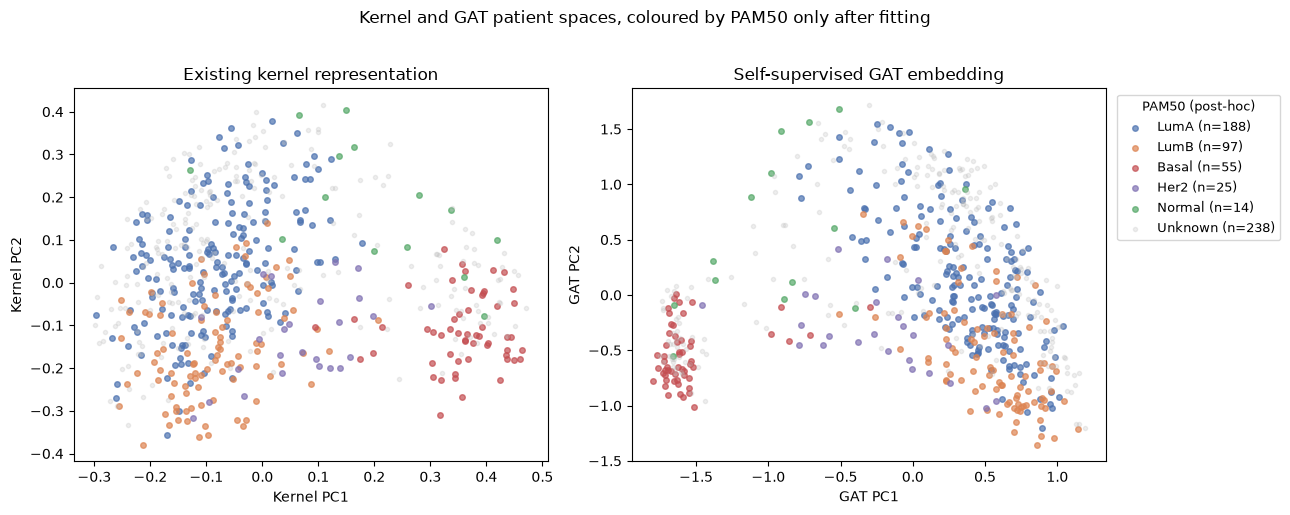

In [8]:
# Post-hoc metrics and visualisation; PAM50 was not used before this point.
gat_2d = PCA(n_components=2, random_state=SEED).fit_transform(gat_embedding)
known_mask = pam50.values != "Unknown"
known_labels = pam50.values[known_mask]
n_classes = len(np.unique(known_labels))

def posthoc_metrics(representation):
    labelled = representation[known_mask]
    predicted = KMeans(n_clusters=n_classes, n_init=20, random_state=SEED).fit_predict(labelled)
    return {
        "silhouette": float(silhouette_score(labelled, known_labels)),
        "ARI": float(adjusted_rand_score(known_labels, predicted)),
        "NMI": float(normalized_mutual_info_score(known_labels, predicted)),
    }

kernel_metrics = posthoc_metrics(embedding)
gat_metrics = posthoc_metrics(gat_2d)
metrics_df = pd.DataFrame([{"Representation": "Kernel PCA", **kernel_metrics},
                           {"Representation": "GAT PCA", **gat_metrics}])
display(metrics_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, representation, title, labels in [
    (axes[0], embedding, "Existing kernel representation", ("Kernel PC1", "Kernel PC2")),
    (axes[1], gat_2d, "Self-supervised GAT embedding", ("GAT PC1", "GAT PC2")),
]:
    for subtype in ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]:
        mask = pam50.values == subtype
        if mask.any():
            ax.scatter(representation[mask, 0], representation[mask, 1],
                       s=16 if subtype != "Unknown" else 9, alpha=.70 if subtype != "Unknown" else .25,
                       color=colors[subtype], label=f"{subtype} (n={mask.sum()})", rasterized=True)
    ax.set(xlabel=labels[0], ylabel=labels[1], title=title)
axes[1].legend(title="PAM50 (post-hoc)", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=9, title_fontsize=9)
fig.suptitle("Kernel and GAT patient spaces, coloured by PAM50 only after fitting", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "TCGA_BRCA_GAT_vs_kernel_PAM50_posthoc.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Inspect which neighbours receive attention

This plot asks an interpretability question that the kernel alone cannot: among a patient's existing graph neighbours, which ones most influence its GAT embedding? The bars summarize learned attention by original neighbour rank, and the right panel draws attention-weighted edges. Attention describes the trained GAT's use of molecular neighbours; it was not learned from PAM50.

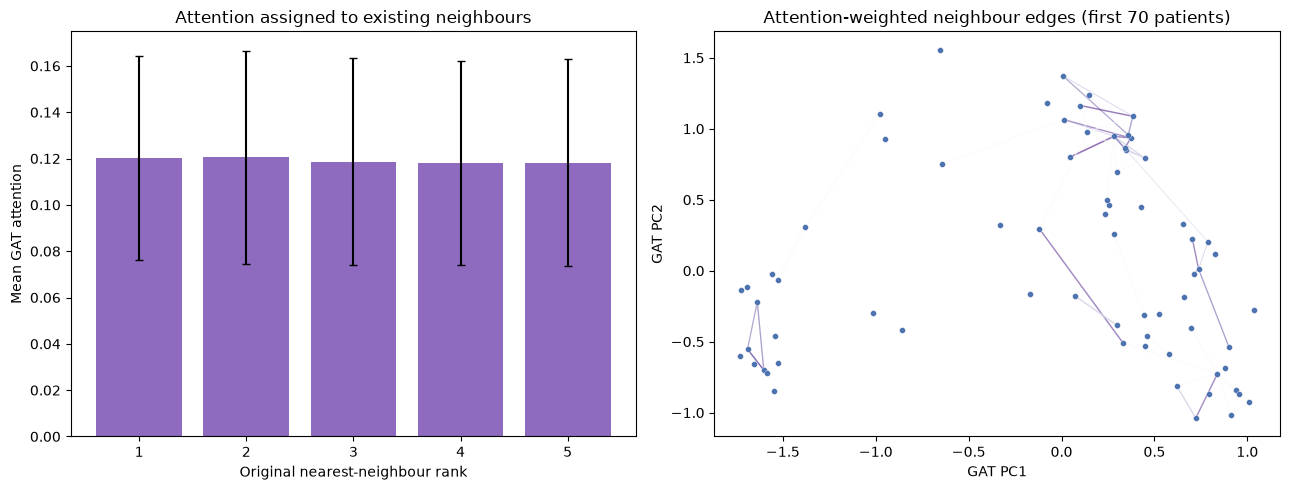

In [9]:
# Attention interpretability: original top-5 neighbour edges, shown without using PAM50.
attention_edges_df = pd.DataFrame({
    "source_patient": [frozen_ids[source] for source, target in directed_edges],
    "target_patient": [frozen_ids[target] for source, target in directed_edges],
    "neighbour_rank": edge_ranks,
    "kernel_similarity": edge_similarities,
    "GAT_attention": original_attention,
})

subset_n_gat = 70
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(rank_attention.index.astype(str), rank_attention["mean"], yerr=rank_attention["std"],
            color="#8E6BBE", capsize=3)
axes[0].set(xlabel="Original nearest-neighbour rank", ylabel="Mean GAT attention",
            title="Attention assigned to existing neighbours")

subset_edges = attention_edges_df[
    attention_edges_df["source_patient"].isin(frozen_ids[:subset_n_gat]) &
    attention_edges_df["target_patient"].isin(frozen_ids[:subset_n_gat])
]
for row in subset_edges.itertuples(index=False):
    source = frozen_ids.index(row.source_patient); target = frozen_ids.index(row.target_patient)
    axes[1].plot([gat_2d[source,0], gat_2d[target,0]], [gat_2d[source,1], gat_2d[target,1]],
                 color=plt.cm.Purples(min(1, row.GAT_attention * 8)), alpha=.55,
                 linewidth=.4 + row.GAT_attention * 6, zorder=1)
axes[1].scatter(gat_2d[:subset_n_gat,0], gat_2d[:subset_n_gat,1], s=18, color="#4C72B0",
                edgecolor="white", linewidth=.25, zorder=2)
axes[1].set(xlabel="GAT PC1", ylabel="GAT PC2",
            title=f"Attention-weighted neighbour edges (first {subset_n_gat} patients)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "TCGA_BRCA_GAT_attention_interpretability.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save concise reproducibility outputs

We save the integrated kernel, nearest-neighbour table, embeddings, attention table, and the existing post-hoc metrics. These files preserve the reported results without adding a new analysis. The checks confirm that the frozen cohort ordering and core graph objects are valid.

In [10]:
pd.DataFrame(K_multi, index=frozen_ids, columns=frozen_ids).to_csv(PROCESSED_DIR / "TCGA_BRCA_kernel_multiomics.tsv", sep="\t", float_format="%.6f")
embedding_df.to_csv(PROCESSED_DIR / "TCGA_BRCA_patient_similarity_embedding.tsv", sep="\t", float_format="%.6f")
neighbors_df.to_csv(PROCESSED_DIR / "TCGA_BRCA_patient_nearest_neighbors.tsv", sep="\t", float_format="%.6f")
gat_scores_df = pd.DataFrame(gat_embedding, index=frozen_ids, columns=[f"GAT_embedding_{i+1}" for i in range(GAT_OUT)])
gat_scores_df.index.name = "sample_id"
gat_scores_df.to_csv(FIGURE_DIR / "TCGA_BRCA_GAT_patient_embeddings.tsv", sep="\t", float_format="%.6f")
attention_edges_df.to_csv(FIGURE_DIR / "TCGA_BRCA_GAT_neighbour_attention.tsv", sep="\t", index=False, float_format="%.6f")
metrics_df.to_csv(FIGURE_DIR / "TCGA_BRCA_GAT_posthoc_metrics.tsv", sep="\t", index=False, float_format="%.6f")
checks = {"kernel": K_multi.shape == (617, 617) and np.isfinite(K_multi).all(), "cohort order": list(rna.index) == frozen_ids, "top-5 graph": len(knn_edges) == len(frozen_ids) * K_NEIGHBORS, "GAT embedding": gat_embedding.shape == (len(frozen_ids), GAT_OUT)}
assert all(checks.values()), checks
print("Saved core kernel and GAT outputs; checks passed.")

Saved core kernel and GAT outputs; checks passed.


## FINAL TAKEAWAY

A similarity kernel captures relationships between patients, but it does not learn how those relationships should influence representations. The GAT turns those relationships into a learned, neighbourhood-aware patient representation, and its attention weights provide an interpretable way to ask which neighbours influence a patient's embedding.

In this dataset, the GAT slightly improves geometric separation but does not improve PAM50 agreement over the simpler kernel. Graph AI should therefore be viewed as a complementary representation-learning approach, not automatically a better model.

So far we have learned representations without directly predicting subtype. Next we move to supervised multimodal prediction and ask whether attention can learn interactions between the molecular views themselves.